In [22]:
import pandas as pd

births = pd.read_csv("data/raw/births_by_state_race.tsv", sep="\t")
deaths = pd.read_csv("data/raw/deaths_by_state_race.tsv", sep="\t")
rural = pd.read_csv("data/raw/NCHSurb-rural-codes.csv", encoding="latin1")

print("BIRTHS")
print(births.columns.tolist())
print(births.head())

print("\nDEATHS")
print(deaths.columns.tolist())
print(deaths.head())

print("\nRURAL")
print(rural.columns.tolist())
print(rural.head())

BIRTHS
['Notes', 'State of Residence', 'State of Residence Code', "Mother's Single Race 6", "Mother's Single Race 6 Code", 'Births']
   Notes State of Residence  State of Residence Code  \
0    NaN            Alabama                      1.0   
1    NaN            Alabama                      1.0   
2  Total            Alabama                      1.0   
3    NaN             Alaska                      2.0   
4    NaN             Alaska                      2.0   

      Mother's Single Race 6 Mother's Single Race 6 Code    Births  
0  Black or African American                      2054-5  118034.0  
1                      White                      2106-3  271703.0  
2                        NaN                         NaN  389737.0  
3  Black or African American                      2054-5    2165.0  
4                      White                      2106-3   37598.0  

DEATHS
['Notes', 'State', 'State Code', 'Single Race 6', 'Single Race 6 Code', 'Deaths', 'Population', 'Crude Rate'

In [23]:
births_clean = births.dropna(subset=["Mother's Single Race 6"]).copy()
births_clean = births_clean[["State of Residence", "Mother's Single Race 6", "Births"]]
births_clean.columns = ["State", "Race", "Births"]

deaths_clean = deaths.dropna(subset=["Single Race 6"]).copy()
deaths_clean = deaths_clean[["State", "Single Race 6", "Deaths", "Population"]]
deaths_clean.columns = ["State", "Race", "Deaths", "Population"]

rural["is_rural"] = rural["CODE2023"] >= 3
rural_state = rural.groupby("ST_ABBREV").agg(
    total_counties=("CTYFIPS", "count"),
    rural_counties=("is_rural", "sum"),
    total_pop=("CTYPOP", "sum")
).reset_index()
rural_state["pct_rural_counties"] = (rural_state["rural_counties"] / rural_state["total_counties"]) * 100

print("BIRTHS CLEAN")
print(births_clean.head())
print("\nDEATHS CLEAN")
print(deaths_clean.head())
print("\nRURAL STATE-LEVEL")
print(rural_state.head())

BIRTHS CLEAN
     State                       Race    Births
0  Alabama  Black or African American  118034.0
1  Alabama                      White  271703.0
3   Alaska  Black or African American    2165.0
4   Alaska                      White   37598.0
6  Arizona  Black or African American   34802.0

DEATHS CLEAN
     State                       Race  Deaths  Population
0  Alabama  Black or African American   108.0   9384181.0
1  Alabama                      White   107.0  24197348.0
2   Alaska                      White    12.0   3318369.0
3  Arizona  Black or African American    29.0   2805255.0
4  Arizona                      White   137.0  42244915.0

RURAL STATE-LEVEL
  ST_ABBREV  total_counties  rural_counties   total_pop  pct_rural_counties
0        AK              35              30    733583.0           85.714286
1        AL              67              60   5074296.0           89.552239
2        AR              75              74   3045637.0           98.666667
3        AZ   

In [24]:
print("Total births in file:", births_clean["Births"].sum())
print("Total deaths in file:", deaths_clean["Deaths"].sum())

Total births in file: 22970400.0
Total deaths in file: 7645.0


In [25]:
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
    'District of Columbia': 'DC'
}

births_clean["ST_ABBREV"] = births_clean["State"].map(state_abbrev)
deaths_clean["ST_ABBREV"] = deaths_clean["State"].map(state_abbrev)

merged = pd.merge(
    deaths_clean,
    births_clean[["State", "Race", "Births"]],
    on=["State", "Race"],
    how="inner"
)

merged["Mortality_Rate_per_100k_Births"] = (merged["Deaths"] / merged["Births"]) * 100000

merged = pd.merge(merged, rural_state, on="ST_ABBREV", how="left")

print("Merged shape:", merged.shape)
print(merged.head(10))
print("\nAny states that failed to map?")
print(merged[merged["pct_rural_counties"].isna()]["State"].unique())

Merged shape: (80, 11)
        State                       Race  Deaths   Population ST_ABBREV  \
0     Alabama  Black or African American   108.0    9384181.0        AL   
1     Alabama                      White   107.0   24197348.0        AL   
2      Alaska                      White    12.0    3318369.0        AK   
3     Arizona  Black or African American    29.0    2805255.0        AZ   
4     Arizona                      White   137.0   42244915.0        AZ   
5    Arkansas  Black or African American    48.0    3331104.0        AR   
6    Arkansas                      White    74.0   16751182.0        AR   
7  California  Black or African American    94.0   17799362.0        CA   
8  California                      White   350.0  195504971.0        CA   
9    Colorado  Black or African American    13.0    1920409.0        CO   

      Births  Mortality_Rate_per_100k_Births  total_counties  rural_counties  \
0   118034.0                       91.499060              67           

In [26]:
# Pivot so Black and White rates sit side-by-side per state
pivot = merged.pivot_table(index=["State", "ST_ABBREV", "pct_rural_counties"], 
                             columns="Race", 
                             values="Mortality_Rate_per_100k_Births").reset_index()

pivot.columns.name = None
pivot = pivot.rename(columns={
    "Black or African American": "Black_Rate",
    "White": "White_Rate"
})

# Only keep states that have both races (some may be missing one due to suppression)
pivot = pivot.dropna(subset=["Black_Rate", "White_Rate"])

pivot["Disparity_Gap"] = pivot["Black_Rate"] - pivot["White_Rate"]
pivot["Disparity_Ratio"] = pivot["Black_Rate"] / pivot["White_Rate"]

print("Number of states with both races present:", len(pivot))
print(pivot[["State", "Black_Rate", "White_Rate", "Disparity_Gap", "Disparity_Ratio", "pct_rural_counties"]].sort_values("Disparity_Gap", ascending=False))

Number of states with both races present: 32
             State  Black_Rate  White_Rate  Disparity_Gap  Disparity_Ratio  \
14          Kansas  119.869856   23.960016      95.909840         5.002912   
40       Tennessee  100.457034   37.684322      62.772713         2.665751   
28      New Jersey   87.815026   25.975072      61.839954         3.380742   
3         Arkansas  100.643700   39.764636      60.879064         2.530985   
22     Mississippi   87.469932   31.301704      56.168229         2.794414   
9          Georgia   84.539163   30.649008      53.890156         2.758300   
2          Arizona   83.328544   30.667225      52.661320         2.717186   
31  North Carolina   85.784430   33.407107      52.377323         2.567850   
0          Alabama   91.499060   39.381236      52.117823         2.323418   
30        New York   74.265026   25.159675      49.105351         2.951748   
23        Missouri   80.210840   31.382028      48.828812         2.555948   
38  South Carolina 

In [27]:
correlation_gap = pivot["pct_rural_counties"].corr(pivot["Disparity_Gap"])
correlation_ratio = pivot["pct_rural_counties"].corr(pivot["Disparity_Ratio"])

print("Correlation between % rural counties and Disparity Gap:", correlation_gap)
print("Correlation between % rural counties and Disparity Ratio:", correlation_ratio)

Correlation between % rural counties and Disparity Gap: 0.160960334323877
Correlation between % rural counties and Disparity Ratio: 0.022187018876184284


In [29]:
pivot2 = pivot.merge(rural_state_weighted[["ST_ABBREV", "pct_rural_population"]], on="ST_ABBREV")

correlation_gap_weighted = pivot2["pct_rural_population"].corr(pivot2["Disparity_Gap"])
correlation_ratio_weighted = pivot2["pct_rural_population"].corr(pivot2["Disparity_Ratio"])

print("Correlation (population-weighted rural %) vs Disparity Gap:", correlation_gap_weighted)
print("Correlation (population-weighted rural %) vs Disparity Ratio:", correlation_ratio_weighted)

Correlation (population-weighted rural %) vs Disparity Gap: 0.26577406702225104
Correlation (population-weighted rural %) vs Disparity Ratio: -0.003854887408535286


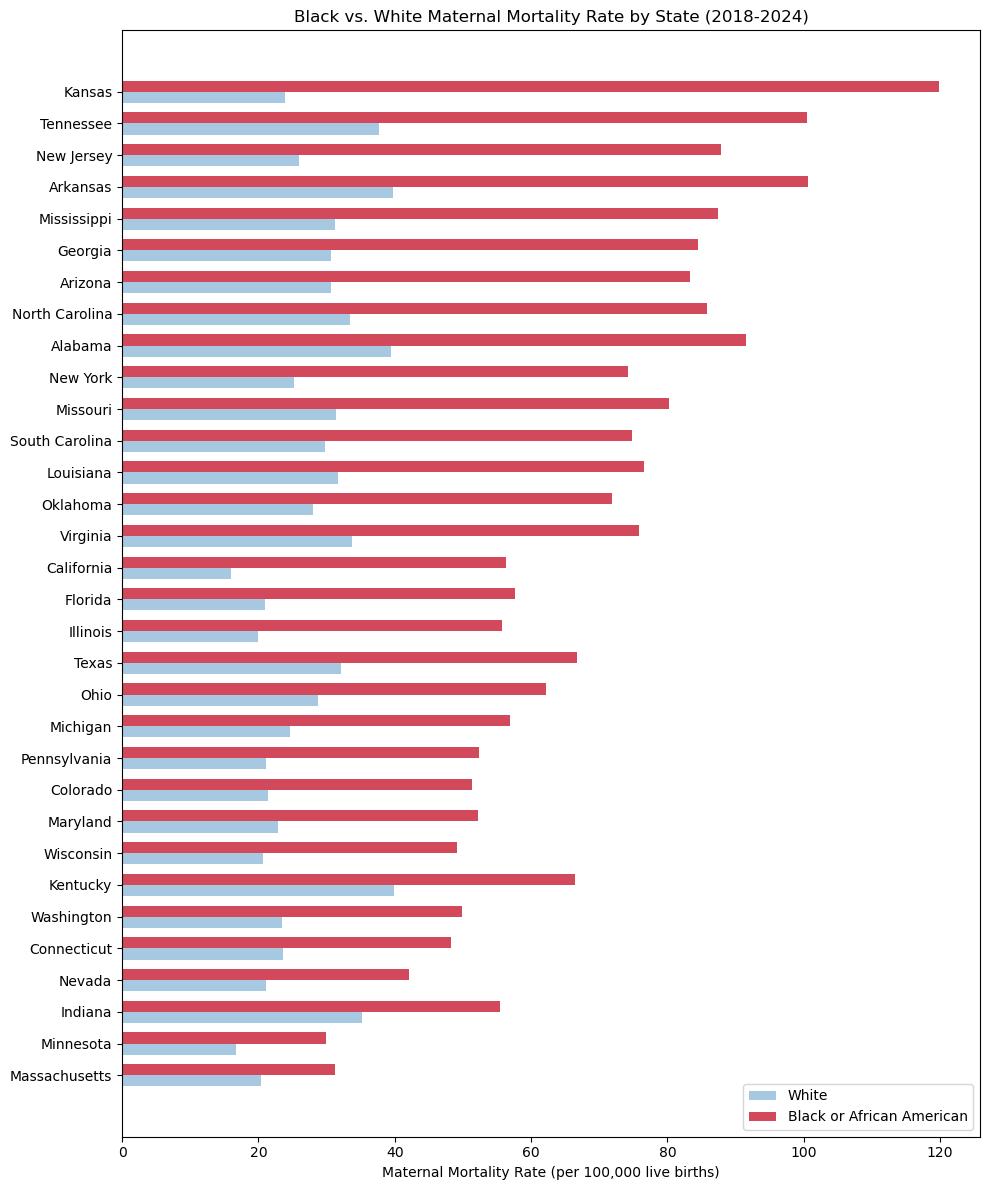

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = pivot2.sort_values("Disparity_Gap", ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))

y_pos = np.arange(len(plot_data))
bar_height = 0.35

ax.barh(y_pos - bar_height/2, plot_data["White_Rate"], height=bar_height, color="#a6c8e0", label="White")
ax.barh(y_pos + bar_height/2, plot_data["Black_Rate"], height=bar_height, color="#d1495b", label="Black or African American")

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data["State"])
ax.set_xlabel("Maternal Mortality Rate (per 100,000 live births)")
ax.set_title("Black vs. White Maternal Mortality Rate by State (2018-2024)")
ax.legend()
plt.tight_layout()
plt.savefig("black_white_mortality_by_state.png", dpi=150)
plt.show()

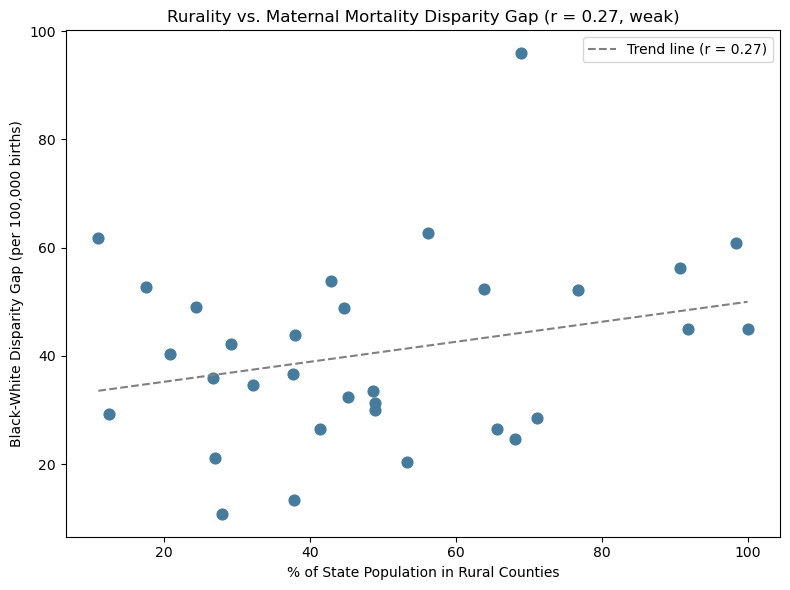

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(pivot2["pct_rural_population"], pivot2["Disparity_Gap"], color="#457b9d", s=60)

z = np.polyfit(pivot2["pct_rural_population"], pivot2["Disparity_Gap"], 1)
trend = np.poly1d(z)
x_range = np.linspace(pivot2["pct_rural_population"].min(), pivot2["pct_rural_population"].max(), 100)
ax.plot(x_range, trend(x_range), color="gray", linestyle="--", label="Trend line (r = 0.27)")

ax.set_xlabel("% of State Population in Rural Counties")
ax.set_ylabel("Black-White Disparity Gap (per 100,000 births)")
ax.set_title("Rurality vs. Maternal Mortality Disparity Gap (r = 0.27, weak)")
ax.legend()
plt.tight_layout()
plt.savefig("rurality_vs_disparity_gap.png", dpi=150)
plt.show()